In [29]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [30]:
#Create dataset 'Glass' with label Encoder and train
df=pd.read_csv('Glass.csv')
# df.columns
# 'RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'
# df.head()
# Type = str
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y=le.fit_transform(df['Type'])
print(y)            #Change numerical
X=df.drop('Type',axis=1)
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=25,stratify=y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 2 2 2 2 2 2 2 2 2 2 2 2 2 4 4 4 4 4 4 4 4 4
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


In [31]:
#Standard Scalar
# solvers=['saga']
# penalty=['l1','l2','elasticnet',None]
# solvers=['sag','newton-cg','newton-cholesky','lbfgs']
# penalty=['l2',None]
# heatmap
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

solvers=['saga']
penalty=['l1','l2','elasticnet',None]
scores=[]
for s in solvers:
    for p in penalty:
        lr=LogisticRegression(solver=s,penalty=p,random_state=25)
        lr.fit(X_train_scaled,y_train)
        y_pred=lr.predict(X_test_scaled)
        scores.append([p,s,accuracy_score(y_test,y_pred)])
df_scored=pd.DataFrame(scores,columns=['penalty','solver','score']).sort_values(ascending=False,by=['score'])
print(df_scored)

      penalty solver     score
0          l1   saga  0.646154
1          l2   saga  0.630769
2  elasticnet   saga  0.630769
3         NaN   saga  0.630769


In [32]:
solvers=['sag','newton-cg','newton-cholesky','lbfgs']
penalty=['l2',None]
scores=[]
for s in solvers:
    for p in penalty:
        lr=LogisticRegression(solver=s,penalty=p,random_state=25)
        lr.fit(X_train_scaled,y_train)
        y_pred=lr.predict(X_test_scaled)
        scores.append([p,s,accuracy_score(y_test,y_pred)])
df_scored=pd.DataFrame(scores,columns=['penalty','solver','score']).sort_values(ascending=False,by=['score'])
print(df_scored)

  penalty           solver     score
7     NaN            lbfgs  0.692308
3     NaN        newton-cg  0.661538
5     NaN  newton-cholesky  0.646154
1     NaN              sag  0.646154
2      l2        newton-cg  0.630769
0      l2              sag  0.630769
4      l2  newton-cholesky  0.630769
6      l2            lbfgs  0.630769


In [33]:
import numpy as np

lr=LogisticRegression(penalty='l2',solver='newton-cg',random_state=25)
lr.fit(X_train_scaled,y_train)
y_pred_prob=lr.predict_proba(X_test_scaled)
df_percent = pd.DataFrame(y_pred_prob * 100)
print(df_percent.round(2).astype(str) + '%')

         0       1       2       3      4       5
0   71.72%  13.92%   0.01%   0.04%  0.18%  14.13%
1   30.49%  54.52%   2.29%   1.63%  1.55%   9.53%
2   43.11%  47.77%   2.23%   1.23%  0.85%   4.81%
3   45.38%  45.71%    2.0%   0.55%  0.57%   5.79%
4   38.02%  47.27%   1.74%   1.72%  2.08%   9.18%
..     ...     ...     ...     ...    ...     ...
60    0.0%   0.92%  23.07%  73.59%  2.42%    0.0%
61  18.02%  71.22%   2.63%    0.1%  0.05%   7.98%
62  11.62%  37.07%   0.62%    0.0%  0.02%  50.67%
63  62.25%  22.23%   0.06%   0.11%   0.3%  15.05%
64   0.91%  72.06%  17.94%   3.56%  1.82%   3.71%

[65 rows x 6 columns]


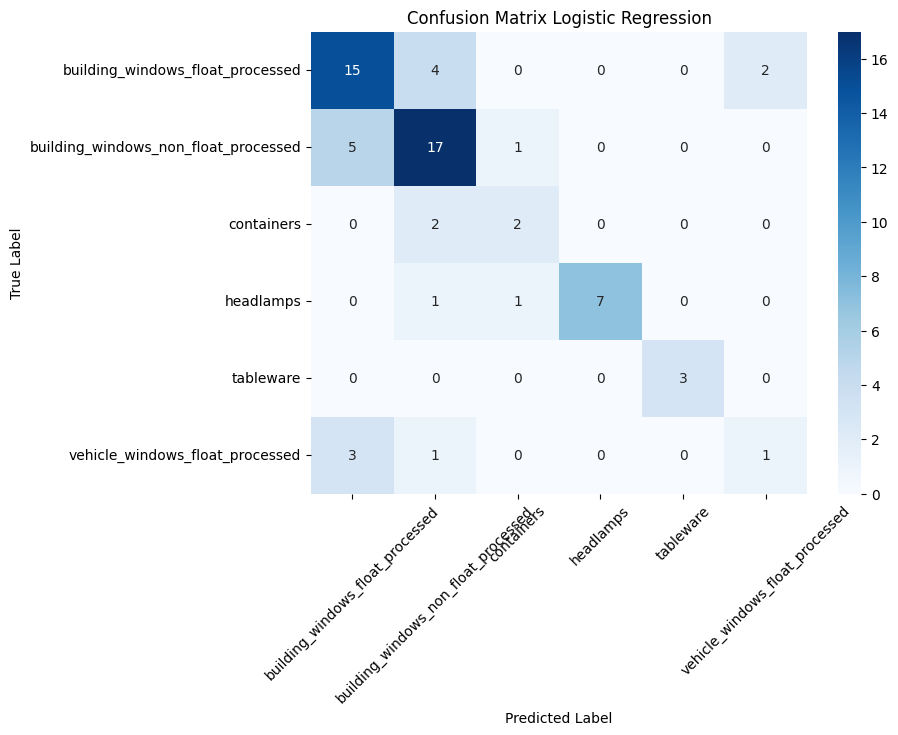

In [34]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import xticks
import seaborn as sns

cm=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=le.classes_,yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Logistic Regression')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [35]:
print(classification_report(y_test,y_pred,target_names=le.classes_))

                                      precision    recall  f1-score   support

    building_windows_float_processed       0.65      0.71      0.68        21
building_windows_non_float_processed       0.68      0.74      0.71        23
                          containers       0.50      0.50      0.50         4
                           headlamps       1.00      0.78      0.88         9
                           tableware       1.00      1.00      1.00         3
     vehicle_windows_float_processed       0.33      0.20      0.25         5

                            accuracy                           0.69        65
                           macro avg       0.69      0.66      0.67        65
                        weighted avg       0.69      0.69      0.69        65

